# 生理约束 MaxEnt：实际数据训练与未来投影

本 Demo 展示课题起始模块，而非后续保护配置。使用实际 Acropora 出现点、背景 SWD 和 GFDL-ESM4 环境栅格抽样，在 Notebook 中重新训练原生 Java MaxEnt，并展示基线及三个 SSP 的无约束/生理约束投影。

这是全球训练数据的固定小子集和固定全球预测位置示例，**不是四类群、三成员、全栅格正式重算**。不人工增加存在记录，不用旧 HSI 充当新模型输出。需 Python 环境和 Java 17+；在仓库根目录打开并 Run All Cells。结果写入 `outputs/physiology_maxent_demo/`。

## 1. 环境与来源

只读输入：1,500 个真实出现记录、10,000 个真实背景记录。固定种子抽样保留父表行号。使用原主线七个最终变量和已选 FC=LQHP、RM=0.5；这里不重做全参数优化。正式父代码使用10次 bootstrap，本小演示训练单个模型，并用固定5°空间块留出检查。背景不是已知缺失。

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
from analysis.modules.physiology_maxent_demo import core

ROOT = Path.cwd()
MODULE = ROOT / "analysis/modules/physiology_maxent_demo"
OUTPUT = ROOT / "outputs/physiology_maxent_demo"
OUTPUT.mkdir(parents=True, exist_ok=True)
manifest = json.loads((MODULE / "provenance.json").read_text(encoding="utf-8"))
core.verify_sources(ROOT, manifest)
JAR = MODULE / "vendor/maxent.jar"
started = time.perf_counter()
print("Native engine: MaxEnt 3.4.4; taxon: Acropora; FC=LQHP; RM=0.5")
print(f"Verified {len(manifest['packaged_files'])} packaged input files")

Native engine: MaxEnt 3.4.4; taxon: Acropora; FC=LQHP; RM=0.5
Verified 11 packaged input files


## 2. 实际输入、单位与空间留出

温度为°C、深度为m、盐度为原环境层单位、Ωarag无量纲。父SWD选定变量完整的记录才进入子集；预测表保留缺失，投影时显式排除不完整位置。按5°块固定留出约20%的空间块，出现点和背景用同一分区，避免同块混入训练与验证。该一次留出不是完整空间交叉验证。

In [2]:
presence = pd.read_csv(MODULE / "data/presence.csv.gz", float_precision="round_trip")
background = pd.read_csv(MODULE / "data/background.csv.gz", float_precision="round_trip")
projection = pd.read_csv(MODULE / "data/projection.csv.gz", float_precision="round_trip")
for frame in (presence, background):
    if not np.isfinite(frame[core.VARIABLES].to_numpy()).all():
        raise ValueError("Non-finite training environment")
    if not frame.longitude.between(-180, 180).all() or not frame.latitude.between(-90, 90).all():
        raise ValueError("Invalid geographic coordinates")
presence_test = core.split_spatial(presence)
background_test = core.split_spatial(background)
display(presence.head())
display(pd.DataFrame({"role": ["presence", "background"],
                      "training": [(~presence_test).sum(), (~background_test).sum()],
                      "spatial_holdout": [presence_test.sum(), background_test.sum()]}))
display(projection.groupby("scenario").complete_environment.agg(["size", "sum"]))

,parent_row,longitude,latitude,bathymetry,rugosity,bottomT,thetao,si,so,zos
0,6,-128.296000,-24.328000,-1952.436938,616.235306,4.703116,26.376141,1.130916,36.408581,0.622883
1,8,-130.111000,-25.078000,-1445.235210,618.877174,6.538621,25.953520,1.137749,36.086613,0.606098
2,19,-138.833333,-9.733333,-825.893878,569.335048,24.030121,27.572954,1.579370,35.563217,0.587176
3,28,-140.666667,-7.900000,-432.781855,650.977031,12.342509,27.512894,1.821683,35.389263,0.585345
4,60,-149.666667,-17.583333,-1019.850468,701.192932,3.151799,27.016296,1.019696,36.005737,0.679037


,role,training,spatial_holdout
0,presence,1306,194
1,background,7911,2089


,size,sum
scenario,,
baseline,2000,1726
ssp126_2050,2000,1726
ssp245_2050,2000,1726
ssp585_2050,2000,1726


## 3. 真正训练原生 MaxEnt

训练使用相关性环境变量，MHW变量不加入训练。LQHP特征和RM来自归档最优设置。关闭外推、开启clamping，不重用已有模型。使用固定原生种子；结果仅代表这个子集。

In [3]:
core.swd(presence.loc[~presence_test], "Acropora", OUTPUT / "training_presence.csv")
core.swd(background.loc[~background_test], "background", OUTPUT / "training_background.csv")
MODEL_DIR = OUTPUT / "model"
MODEL_DIR.mkdir(exist_ok=True)
arguments = ["density.MaxEnt", "-z",
             f"samplesfile={OUTPUT / 'training_presence.csv'}",
             f"environmentallayers={OUTPUT / 'training_background.csv'}",
             f"outputdirectory={MODEL_DIR}",
             "betamultiplier=0.5", "autofeature=false", "linear=true", "quadratic=true",
             "product=true", "hinge=true", "threshold=false", "randomseed=false",
             "maximumbackground=-1", "threads=2", "extrapolate=false", "doclamp=true",
             "fadebyclamping=false", "outputformat=logistic", "askoverwrite=false",
             "responsecurves=false", "jackknife=false", "pictures=false"]
training_started = int(time.time())
training_log = core.run_java(JAR, arguments, OUTPUT / "training.log")
MODEL = MODEL_DIR / "Acropora.lambdas"
if not MODEL.is_file():
    raise RuntimeError("Native MaxEnt produced no fitted model")
if MODEL.stat().st_mtime < training_started:
    raise RuntimeError("Fitted model timestamp is stale")
display(pd.read_csv(MODEL_DIR / "maxentResults.csv"))
print("Newly fitted model:", MODEL.name)

,Species,#Training samples,Regularized training gain,Unregularized training gain,Iterations,Training AUC,#Background points,bathymetry contribution,bottomT contribution,rugosity contribution,...,Maximum training sensitivity plus specificity area,Maximum training sensitivity plus specificity training omission,"Balance training omission, predicted area and threshold value cumulative threshold","Balance training omission, predicted area and threshold value Logistic threshold","Balance training omission, predicted area and threshold value area","Balance training omission, predicted area and threshold value training omission",Equate entropy of thresholded and original distributions cumulative threshold,Equate entropy of thresholded and original distributions Logistic threshold,Equate entropy of thresholded and original distributions area,Equate entropy of thresholded and original distributions training omission
0,Acropora,1158,1.1917,1.2386,500,0.8855,9069,3.0973,21.5566,4.9248,...,0.2547,0.0354,2.1228,0.0864,0.3434,0.0095,3.7868,0.1468,0.3047,0.0164


Newly fitted model: Acropora.lambdas


## 4. 新模型空间留出验证与真实情景投影

使用原生引擎读取刚训练的lambdas文件。投影采用父代码的 `doclamp=true, extrapolate=false, fadebyclamping=true`。Logistic输出作为HSI指标，不解释为无条件出现概率。AUC是出现—背景区分度，不是出现—真实缺失分类准确率。

基线与SSP126/245/585使用同一2,000个全球背景位置；底形与粗糙度取原SWD静态值，其他字段从对应GFDL实际栅格抽取。未补造缺失环境值。

In [4]:
def scores(frame, label):
    valid, native = core.project(JAR, MODEL, frame, OUTPUT, label)
    result = pd.Series(np.nan, index=frame.index)
    prediction_columns = [column for column in native.columns
                          if column not in ["species", "longitude", "latitude"]]
    if len(prediction_columns) != 1:
        raise ValueError(f"Unexpected native prediction columns: {list(native.columns)}")
    values = native[prediction_columns[0]].to_numpy()
    if len(values) != valid.sum() or not np.isfinite(values).all():
        raise ValueError("Incomplete native projection")
    np.testing.assert_allclose(native[["longitude", "latitude"]].to_numpy(),
                               frame.loc[valid, ["longitude", "latitude"]].to_numpy(),
                               rtol=0, atol=1e-5)
    result.loc[valid] = values
    return result

positive_scores = scores(presence.loc[presence_test], "holdout_presence")
negative_scores = scores(background.loc[background_test], "holdout_background")
holdout_auc = core.auc(positive_scores, negative_scores)
print(f"Spatial holdout presence-background AUC: {holdout_auc:.6f}")
results = []
for scenario, frame in projection.groupby("scenario", sort=False):
    frame = frame.copy()
    frame["hsi_unconstrained"] = scores(frame, scenario)
    results.append(frame)
predictions = pd.concat(results, ignore_index=True)
training_environment = pd.concat([presence.loc[~presence_test, core.VARIABLES],
                                  background.loc[~background_test, core.VARIABLES]])
outside = ((predictions[core.VARIABLES] < training_environment.min())
           | (predictions[core.VARIABLES] > training_environment.max()))
predictions["outside_training_range_variables"] = outside.sum(axis=1)
predictions["novelty_check_applicable"] = predictions[core.VARIABLES].notna().all(axis=1)
display(predictions.loc[predictions.novelty_check_applicable].groupby("scenario").outside_training_range_variables.agg(["count", "max", "mean"]))

holdout_presence: native output columns ['longitude', 'latitude', 'Acropora logistic values']


holdout_background: native output columns ['longitude', 'latitude', 'Acropora logistic values']
Spatial holdout presence-background AUC: 0.952246


baseline: native output columns ['longitude', 'latitude', 'Acropora logistic values']


ssp126_2050: native output columns ['longitude', 'latitude', 'Acropora logistic values']


ssp245_2050: native output columns ['longitude', 'latitude', 'Acropora logistic values']


ssp585_2050: native output columns ['longitude', 'latitude', 'Acropora logistic values']


,count,max,mean
scenario,,,
baseline,1726,1,0.002317
ssp126_2050,1726,1,0.001159
ssp245_2050,1726,1,0.001159
ssp585_2050,1726,1,0.001159


## 5. 生理约束：温度响应 × 碳酸盐响应

按父投影代码，`HSI_constrained = HSI_MaxEnt × Φ^0.5`，其中Φ为不对称高斯TPC与Ωarag sigmoid的乘积。Topt=27°C，冷端σ=5°C，热端σ=2°C，Ω中点=3，陡峭度=4。它是**投影后的乘法约束**，不是生理层嵌入训练或修改MaxEnt目标函数。

这些参数是原项目的结构化假设，不是本Demo拟合的实验结果；不声称已证明约束改善了预测能力。本实现不将MHW急性胁迫再次计入Φ。

In [5]:
predictions["physiology_effective_multiplier"] = core.coral_multiplier(
    predictions.thetao, predictions.omega_arag)
predictions["hsi_constrained"] = predictions.hsi_unconstrained * predictions.physiology_effective_multiplier
valid = predictions[["hsi_unconstrained", "hsi_constrained"]].notna().all(axis=1)
if not predictions.loc[valid, "hsi_constrained"].between(0, 1).all():
    raise ValueError("Constrained HSI outside [0, 1]")
if (predictions.loc[valid, "hsi_constrained"] > predictions.loc[valid, "hsi_unconstrained"] + 1e-12).any():
    raise ValueError("Coral constraint increased HSI")
predictions.to_csv(OUTPUT / "projection_predictions.csv.gz", index=False, float_format="%.17g")
summary = predictions.groupby("scenario").agg(
    locations=("location_id", "size"), valid_hsi=("hsi_constrained", "count"),
    mean_unconstrained=("hsi_unconstrained", "mean"), mean_constrained=("hsi_constrained", "mean"))
summary.to_csv(OUTPUT / "scenario_summary.csv", float_format="%.17g")
display(summary)

,locations,valid_hsi,mean_unconstrained,mean_constrained
scenario,,,,
baseline,2000,1726,0.043007,0.036909
ssp126_2050,2000,1726,0.047671,0.037229
ssp245_2050,2000,1726,0.048217,0.035923
ssp585_2050,2000,1726,0.049357,0.033463


## 6. 查看模型投影与约束效果

图件直接使用以上新模型结果。图上点为实际抽取位置，不代表连续全球礁区栅格；情景均值为抽样位置简单均值，不是全球礁区面积加权结果。环境新颖性与clamping单独解释，不能把未来投影当作经未来观测验证的事实。

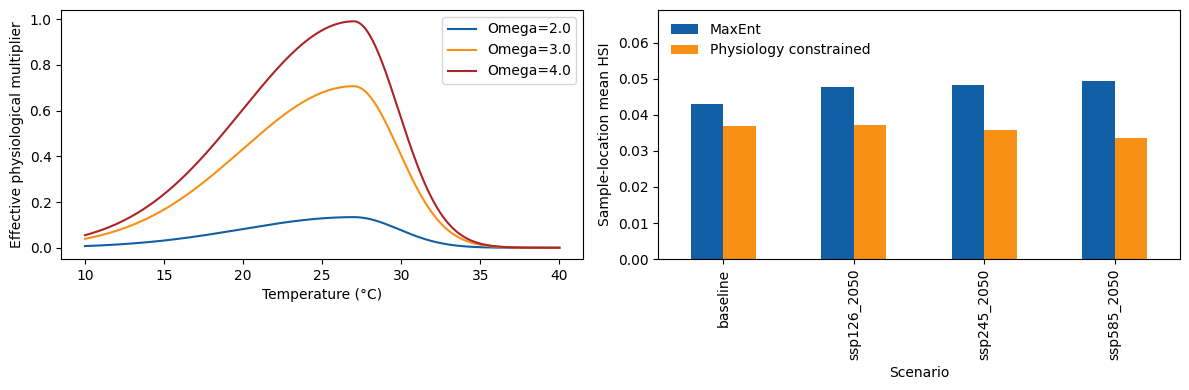

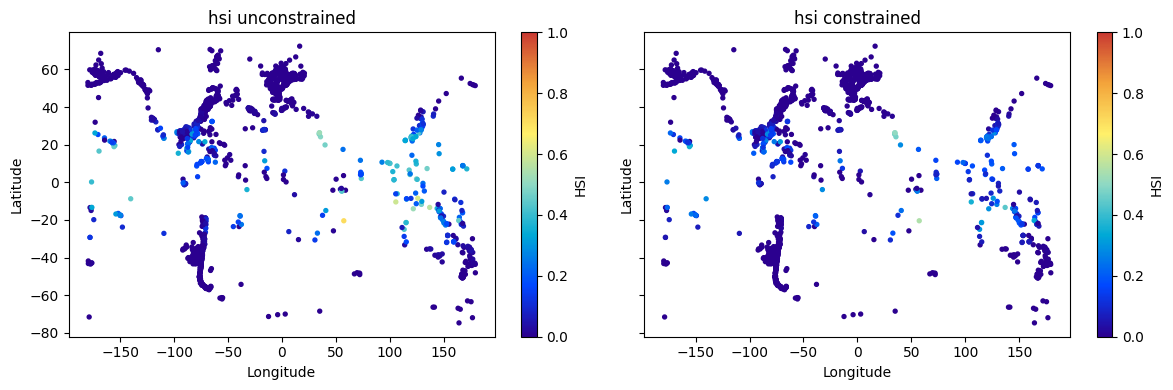

In [6]:
temperature = np.linspace(10, 40, 301)
plt.rcParams.update({"svg.fonttype": "none", "pdf.fonttype": 42})
figure_spec = {"paired_colors": ["#115FA4", "#F79015"], "map_limits": [0, 1]}
cmap = LinearSegmentedColormap.from_list("project_hsi", [
    "#2B008F", "#0047FF", "#00A9D6", "#8ED9C4", "#FFF06A", "#F3A43B", "#C93A32"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for omega, color in zip([2.0, 3.0, 4.0], ["#115FA4", "#F79015", "#AB2428"]):
    axes[0].plot(temperature, core.coral_multiplier(temperature, omega), label=f"Omega={omega}", color=color)
axes[0].set(xlabel="Temperature (°C)", ylabel="Effective physiological multiplier")
axes[0].legend()
summary[["mean_unconstrained", "mean_constrained"]].plot.bar(ax=axes[1], color=figure_spec["paired_colors"])
axes[1].set(ylabel="Sample-location mean HSI", xlabel="Scenario")
axes[1].legend(["MaxEnt", "Physiology constrained"], loc="upper left", frameon=False)
axes[1].set_ylim(0, summary.mean_unconstrained.max() * 1.4)
fig.tight_layout()
fig.savefig(OUTPUT / "physiology_and_projection.png", dpi=160)
for extension in ["svg", "pdf"]:
    fig.savefig(OUTPUT / f"physiology_and_projection.{extension}")
plt.show()
future = predictions.loc[predictions.scenario == "ssp585_2050"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for axis, column in zip(axes, ["hsi_unconstrained", "hsi_constrained"]):
    points = axis.scatter(future.longitude, future.latitude, c=future[column], s=8,
                          cmap=cmap, vmin=0, vmax=1)
    axis.set(title=column.replace("_", " "), xlabel="Longitude", ylabel="Latitude")
    fig.colorbar(points, ax=axis, label="HSI")
fig.tight_layout()
fig.savefig(OUTPUT / "ssp585_sample_projection.png", dpi=160)
for extension in ["svg", "pdf"]:
    fig.savefig(OUTPUT / f"ssp585_sample_projection.{extension}")
plt.show()

## 7. 保存运行证据与限制

来源哈希、训练日志、拟合参数、留出AUC和投影表随结果保存。不用原正式模型AUC冒充小样本性能。没有重新估计生理参数，没有进行四类群完整优化、10次bootstrap或三成员集合；这条Notebook验证的是可运行的训练→投影→约束流程。

In [7]:
core.verify_sources(ROOT, manifest)
report = {"status": "passed", "entrypoint": "Physiology_MaxEnt_demo.ipynb",
          "taxon": "Acropora", "native_maxent_version": "3.4.4",
          "presence_rows": len(presence), "background_rows": len(background),
          "training_presence_rows": int((~presence_test).sum()),
          "training_background_rows": int((~background_test).sum()),
          "spatial_holdout_presence_background_auc": holdout_auc,
          "projection_rows": len(predictions), "valid_constrained_rows": int(valid.sum()),
          "elapsed_seconds": round(time.perf_counter() - started, 3),
          "full_parent_reproduction": False,
          "constraint_location": "Post-projection multiplication, not training-objective modification",
          "original_sources_modified": False}
(OUTPUT / "run_checks.json").write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame([report]))

,status,entrypoint,taxon,native_maxent_version,presence_rows,background_rows,training_presence_rows,training_background_rows,spatial_holdout_presence_background_auc,projection_rows,valid_constrained_rows,elapsed_seconds,full_parent_reproduction,constraint_location,original_sources_modified
0,passed,Physiology_MaxEnt_demo.ipynb,Acropora,3.4.4,1500,10000,1306,7911,0.952246,8000,6904,17.872,False,"Post-projection multiplication, not training-o...",False
